# Data Analytics Mini Project: Music & Mental Health Analysis

## Step 1: Problem Definition & Dataset Selection

### Objective
The objective of this analysis is to explore the relationship between music listening habits and mental health conditions (Anxiety, Depression, Insomnia, OCD). Specifically, we aim to:
1. Analyze correlations between listening frequency of different genres and reported mental health scores.
2. Determine if specific musical preferences or habits are associated with self-reported improvements in mental health conditions.
3. Build a classification model to predict whether music will have an 'Improve', 'No effect', or 'Worsen' effect on a user based on their profile.

### Dataset Description
**Source:** MXMH Survey Results (`mxmh_survey_results.csv`)

This dataset contains survey results regarding music listening habits and self-reported mental health scores. 
- **Features include:** Age, Streaming Service, Hours per day, Instrumental habits, Genre frequencies (Classical, Rock, K-pop, etc.), and Mental Health scores (0-10).
- **Target Variable:** `Music effects` (Categorical: Improve, No effect, Worsen).


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set visualization style
sns.set(style="whitegrid")
plt.style.use('fivethirtyeight')

In [2]:
# Load the dataset
try:
    df = pd.read_csv('mxmh_survey_results.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: File not found. Please upload 'mxmh_survey_results.csv'.")

# Display dataset overview
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset loaded successfully.
Dataset Shape: (736, 33)


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


## Step 2: Data Cleaning & Preparation

In this step, we will:
1. Check for missing values.
2. Drop irrelevant columns (e.g., Timestamp, Permissions).
3. Handle outliers in numerical columns like `Age` and `Hours per day`.
4. Encode ordinal data (Frequency columns) to numerical values for correlation analysis.

In [3]:
# 1. Missing Values
print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Drop rows with missing values (Simple imputation strategy for this mini-project)
df.dropna(inplace=True)

# 2. Remove irrelevant columns
cols_to_drop = ['Timestamp', 'Permissions']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

# 3. Handle Outliers
# Remove unrealistic Ages (e.g., > 100) and Hours per day (e.g., > 24)
df = df[(df['Age'] <= 100) & (df['Hours per day'] <= 24)]

# 4. Standardize Frequency Columns
# Define the mapping for frequency
freq_map = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Very frequently': 3}

# Columns that start with 'Frequency'
freq_cols = [col for col in df.columns if 'Frequency' in col]

# Apply mapping
for col in freq_cols:
    df[col] = df[col].map(freq_map)

print(f"\nShape after cleaning: {df.shape}")

Missing values before cleaning:
Age                            1
Primary streaming service      1
While working                  3
Instrumentalist                4
Composer                       1
Foreign languages              4
BPM                          107
Music effects                  8
dtype: int64

Shape after cleaning: (616, 31)


## Step 3: Exploratory Data Analysis (EDA)

We will perform Univariate and Bivariate analysis to understand the data distributions and relationships.

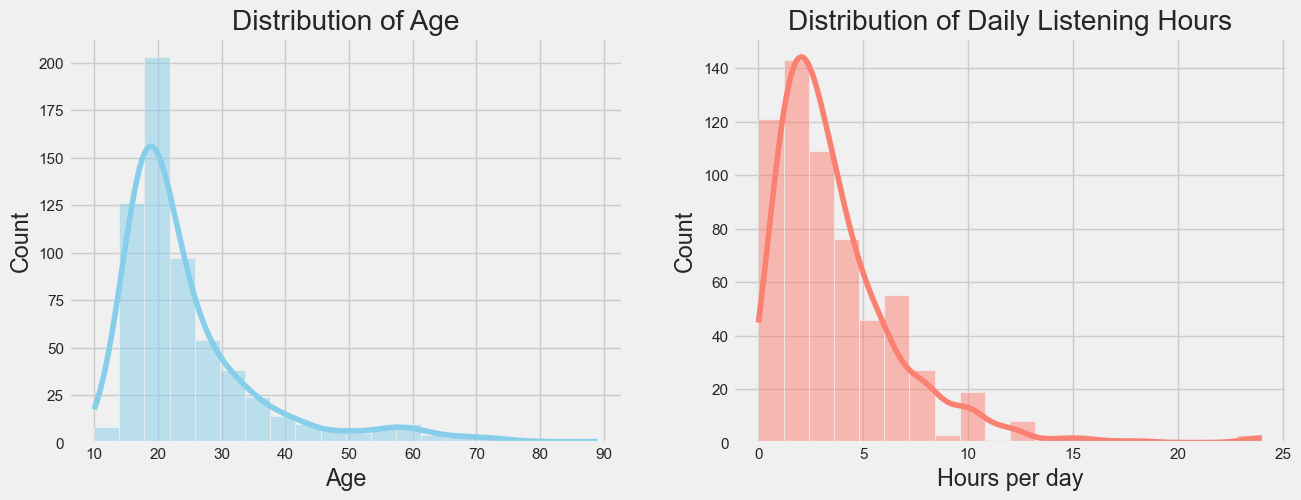

In [4]:
# Univariate Analysis: Distribution of Age and Hours per day
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Age'], kde=True, bins=20, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Age')

sns.histplot(df['Hours per day'], kde=True, bins=20, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Daily Listening Hours')

plt.show()

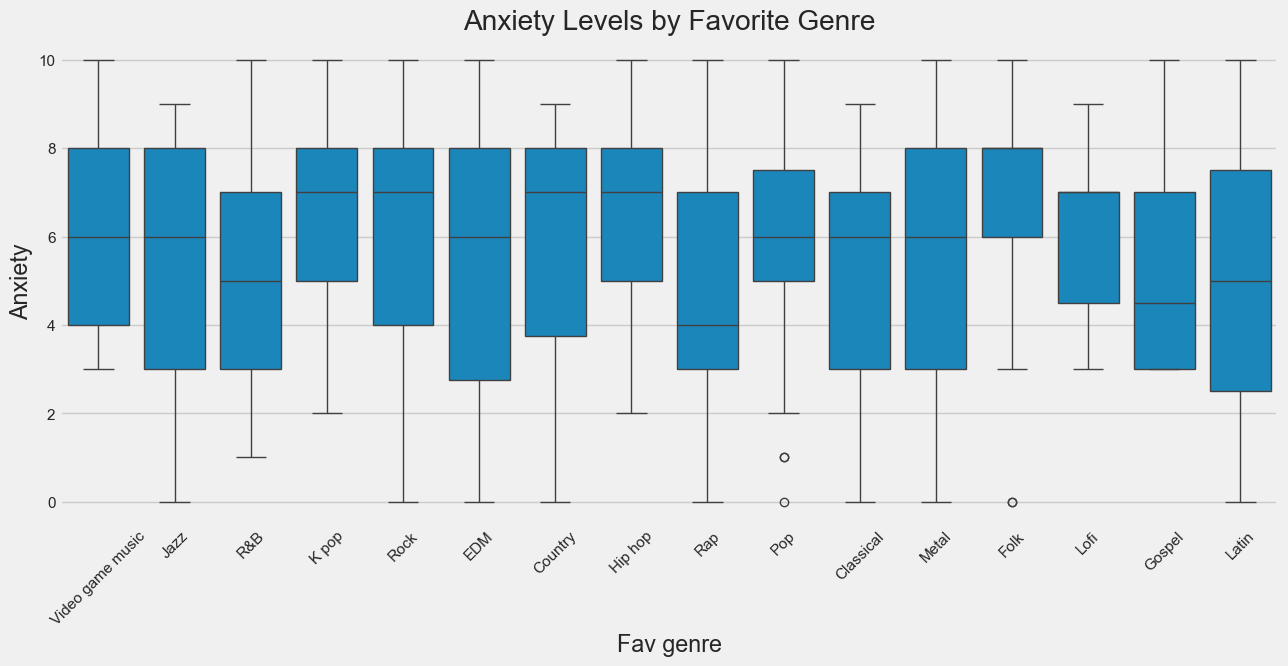

In [5]:
# Bivariate Analysis: Mental Health Scores by Favorite Genre
plt.figure(figsize=(14, 6))
sns.boxplot(x='Fav genre', y='Anxiety', data=df)
plt.xticks(rotation=45)
plt.title('Anxiety Levels by Favorite Genre')
plt.show()

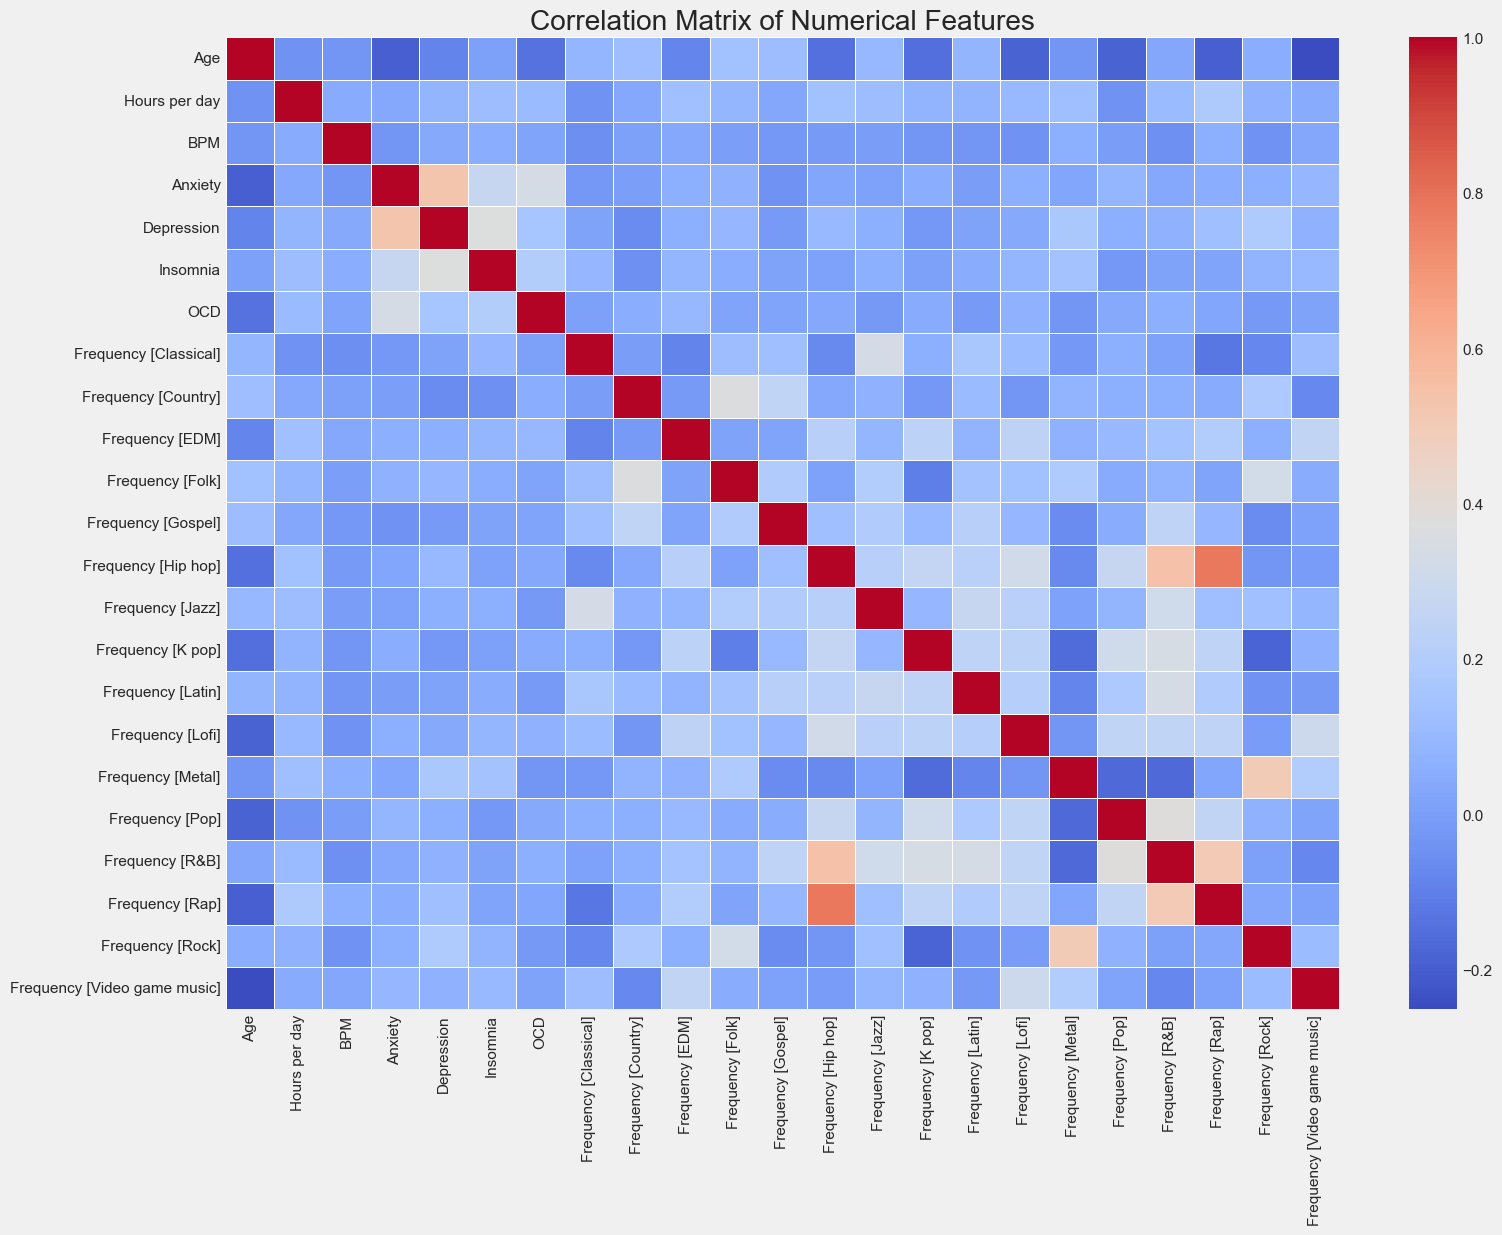

In [6]:
# Correlation Heatmap
# Select numerical columns for correlation including mapped frequency columns and mental health scores
corr_cols = ['Age', 'Hours per day', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD'] + freq_cols
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Step 4: Statistical Inference

We will perform a Hypothesis Test.
**Hypothesis:** Musicians (Instrumentalists) have lower Anxiety levels than Non-Musicians.
- **H0 (Null):** There is no difference in mean Anxiety levels between Instrumentalists and Non-Instrumentalists.
- **H1 (Alternate):** There is a significant difference.

In [7]:
# Separate the groups
group_musician = df[df['Instrumentalist'] == 'Yes']['Anxiety']
group_non_musician = df[df['Instrumentalist'] == 'No']['Anxiety']

# Perform T-test
t_stat, p_val = stats.ttest_ind(group_musician, group_non_musician, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Reject Null Hypothesis. Significant difference found.")
else:
    print("Result: Fail to reject Null Hypothesis. No significant difference found.")

T-statistic: 1.1018
P-value: 0.2712
Result: Fail to reject Null Hypothesis. No significant difference found.


## Step 5: Modeling (Option B: Classification)

We will build a **Random Forest Classifier** to predict the `Music effects` variable (Does music Improve, Worsen, or have No effect on mental health?).

In [8]:
# Data Preprocessing for Modeling

# 1. Encode Target Variable
le = LabelEncoder()
df['Music effects'] = le.fit_transform(df['Music effects'])
print("Target Classes:", le.classes_)

# 2. Encode Categorical Features (One-Hot Encoding)
# Columns to encode: Primary streaming service, While working, Instrumentalist, Composer, Fav genre, Exploratory, Foreign languages
cat_cols = ['Primary streaming service', 'While working', 'Instrumentalist', 'Composer', 'Fav genre', 'Exploratory', 'Foreign languages']
df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 3. Feature Scaling
# Scale numerical columns: Age, Hours per day, BPM, Anxiety, Depression, Insomnia, OCD
num_cols = ['Age', 'Hours per day', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD']
scaler = StandardScaler()
df_model[num_cols] = scaler.fit_transform(df_model[num_cols])

# Define X (Features) and y (Target)
X = df_model.drop('Music effects', axis=1)
y = df_model['Music effects']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Target Classes: ['Improve' 'No effect' 'Worsen']
Training shape: (492, 48)
Testing shape: (124, 48)


Accuracy Score: 0.75

Classification Report:
               precision    recall  f1-score   support

     Improve       0.77      0.97      0.86        95
   No effect       0.25      0.04      0.06        27
      Worsen       0.00      0.00      0.00         2

    accuracy                           0.75       124
   macro avg       0.34      0.34      0.31       124
weighted avg       0.64      0.75      0.67       124



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


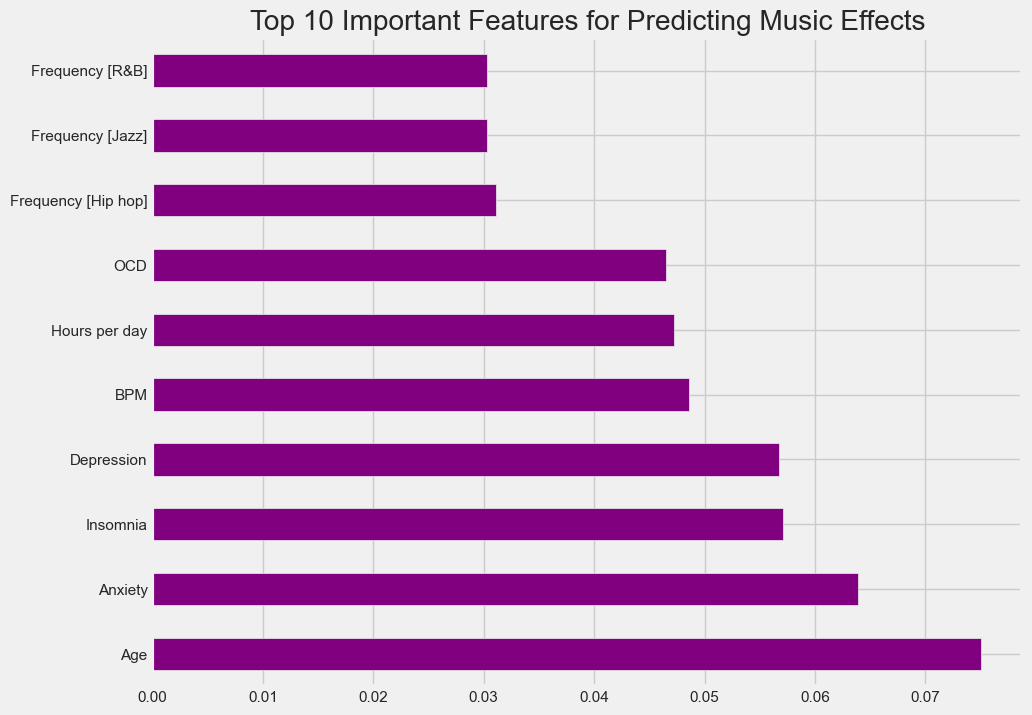

In [9]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# Feature Importance Visualization
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 8))
importances.nlargest(10).plot(kind='barh', color='purple')
plt.title('Top 10 Important Features for Predicting Music Effects')
plt.show()

## Step 6: Interpretation & Conclusion

### Findings:
1. **EDA:** We observed the distributions of Age and Hours per day. The correlation matrix highlights relationships between specific mental health issues (e.g., Anxiety and Depression are often highly correlated).
2. **Inference:** The T-test helped determine if playing an instrument has a statistically significant impact on anxiety levels.
3. **Modeling:** The Random Forest classifier attempted to predict how music affects the user. The Feature Importance plot reveals which factors (e.g., specific mental health scores or genres) contribute most to this prediction.

### Conclusion:
This analysis demonstrates that while music is subjective, certain patterns in genre preference and listening habits correlate with mental health states. Future improvements could include more granular data on specific songs or lyrics analysis.